In [2]:
import pandas as pd
import numpy as np

In [3]:
data=pd.read_csv('2027Scheduler.csv')
#data=pd.read_excel('2026Scheduler.xlsx',sheet_name='ConductCounter')
data.head()

,Index,DateStart,DateEnd,Course,Center
0,Mandala1,2027/01/08,2027/01/19,10D,Mandala
1,Mandala2,2027/02/02,2027/02/17,GC,Mandala
2,Mandala3,2027/02/20,2027/03/23,30D,Mandala
3,Mandala4,2027/04/09,2027/04/20,10D,Mandala
4,Mandala5,2027/05/20,2027/05/31,10D,Mandala


In [4]:
course_count_by_center = data.groupby(['Center', 'Course']).size().reset_index(name='count')
print(course_count_by_center)

         Center     Course  count
0         Canda        10D      4
1         Canda  TeenGirls      1
2          Joti        10D     16
3          Joti         3D      3
4          Joti         GC      1
5          Joti        STP      2
6          Joti   TeenBoys      1
7          Joti  TeenGirls      1
8         Labha        10D      6
9         Labha        STP      1
10        Magga        10D     11
11  MahaPabatta        10D     10
12  MahaPabatta        STP      1
13      Mahima1        10D      7
14      Mahima1        STP      1
15      Mahima1  TeenGirls      1
16      Mahima2        10D     12
17      Mahima2        20D      2
18      Mahima2       S10D      1
19      Mahima2        STP      1
20       Makuta        10D      9
21       Makuta        STP      1
22      Mandala        10D     11
23      Mandala        30D      1
24      Mandala         GC      1
25      Mandala       S10D      1
26      Mandala        STP      1
27         Mani        10D      5
28         Man

In [5]:
data.groupby(["Center","Course"])["Course"].count().to_csv('2027CourseCount.csv')

In [6]:
# Create Pivot Table
# map Mahima1/Mahima2 → Mahima then group and aggregate
data['Center'] = data['Center'].replace({'Mahima1': 'Mahima', 'Mahima2': 'Mahima'})

df = pd.pivot_table(data, index='Center', columns='Course', aggfunc='size', fill_value=0)

# add sum col in pivot table
df['Sum'] = df.sum(axis=1)

pivot_table=df.sort_values(by="Sum", ascending=False)

# save pivot_table to csv
pivot_table.to_csv('Courses2027PivotSummary.csv')

# Display the pivot table
print('2027 Vipassana Courses in Myanmar:')
print(' excluding 1D-2D Short courses')
print()
print(pivot_table)

2027 Vipassana Courses in Myanmar:
 excluding 1D-2D Short courses

Course       10D  20D  30D  3D  45D  GC  S10D  STP  TeenBoys  TeenGirls  Sum
Center                                                                      
Mahima        19    2    0   0    0   0     1    2         0          1   25
Joti          16    0    0   3    0   1     0    2         1          1   24
Mandala       11    0    1   0    0   1     1    1         0          0   15
Nidhi          8    1    2   0    2   0     1    1         0          0   15
Magga         11    0    0   0    0   0     0    0         0          0   11
MahaPabatta   10    0    0   0    0   0     0    1         0          0   11
Manohara       8    0    0   0    0   0     0    1         0          1   10
Makuta         9    0    0   0    0   0     0    1         0          0   10
Manorama       6    0    0   1    0   0     0    1         1          1   10
Nanadhaja      6    0    0   1    0   0     0    1         0          0    8
Pabbata  

In [7]:
# Courses in Jan and Feb

import pandas as pd
import numpy as np
from datetime import date

# --- 1. Create Sample Data (Simulation) ---
# We create a sample DataFrame to demonstrate the filtering process.


df = pd.DataFrame(data)

# Convert the date columns to datetime objects (Crucial step for filtering)
df['DateStart'] = pd.to_datetime(df['DateStart'])
df['DateEnd'] = pd.to_datetime(df['DateEnd'])


# --- 2. Define the Filtering Logic ---

# Goal: Select data where EITHER DateStart OR DateEnd falls in January (1) or February (2).

# Filter condition for 'DateStart': Check if the month is 1 (Jan) or 2 (Feb)
condition_start = df['DateStart'].dt.month.isin([1, 2])

# Filter condition for 'DateEnd': Check if the month is 1 (Jan) or 2 (Feb)
condition_end = df['DateEnd'].dt.month.isin([1, 2])


# --- 3. Apply the Combined Filter ---
# We use the logical OR operator (|) to select rows that meet either condition.
filtered_df = df[condition_start | condition_end] [['Center','Course','DateStart','DateEnd']]

filtered_df.to_csv('Center_Courses_JanFeb.csv')


# --- 4. Display the Results ---
#print("--- Original DataFrame ---")
#print(df)
print("\n" + "="*50)
print("--- Filtered Centers and Courses in (Jan/Feb ) ---")
print(filtered_df)



--- Filtered Centers and Courses in (Jan/Feb ) ---
          Center Course  DateStart    DateEnd
0        Mandala    10D 2027-01-08 2027-01-19
1        Mandala     GC 2027-02-02 2027-02-17
2        Mandala    30D 2027-02-20 2027-03-23
15     MittaYana    10D 2027-01-21 2027-02-01
16     MittaYana    10D 2027-02-23 2027-03-06
22          Mani    10D 2027-01-08 2027-01-19
29   MahaPabatta    10D 2027-02-18 2027-03-01
40          Shwe    10D 2027-02-19 2027-03-02
53    Mayuradipa    10D 2027-01-08 2027-01-19
54    Mayuradipa    10D 2027-02-11 2027-02-22
60      Manorama    10D 2027-02-02 2027-02-13
70      Manohara    10D 2027-01-08 2027-01-19
71      Manohara    10D 2027-02-10 2027-02-21
94        Makuta    10D 2027-02-15 2027-02-26
104       Mahima    10D 2027-02-09 2027-02-20
105       Mahima    10D 2027-02-24 2027-03-07
134        Magga    10D 2027-01-08 2027-01-19
135        Magga    10D 2027-02-11 2027-02-22
145         Joti     3D 2027-01-01 2027-01-04
146         Joti    10D 2027

In [10]:
import pandas as pd
import plotly.express as px

# Create a DataFrame
df = data

# Count the occurrences of each category
course_counts = df['Course'].value_counts().reset_index()
course_counts.columns = ['Course', 'count']

# Create a bar plot using Plotly Express
fig = px.bar(course_counts, x='Course', y='count', title='Course Type Count', labels={'count': 'Number of Courses', 'Course': 'CourseType'})

# Show the plot
fig.show()


In [11]:
import plotly.express as px
fig=px.bar(data,x='Center', y= 'Course',color='Course',title='Vipassana Courses in MM Centers 2027 (Stack Bar Plot)')
fig.show()

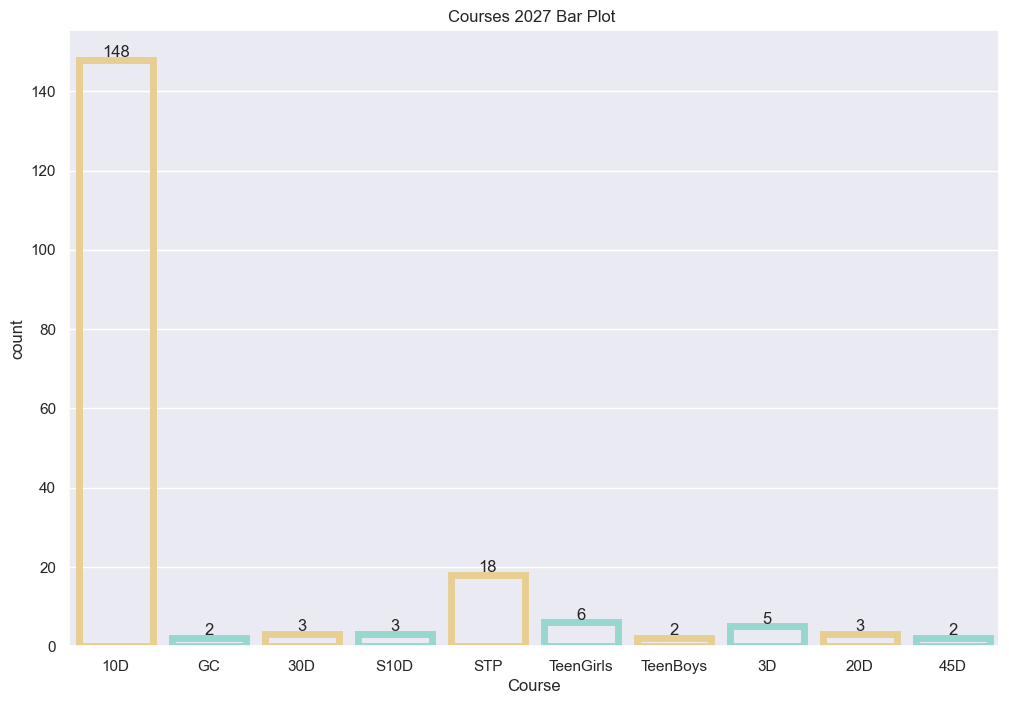

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(rc={'figure.figsize':(12,8)})

ax=sns.countplot(x ='Course', data = data,color="salmon", facecolor=(0, 0, 0, 0),
                linewidth=5,
                edgecolor=sns.color_palette("BrBG", 2))

for container in ax.containers:
    ax.bar_label(container)
# Show the plot

plt.title('Courses 2027 Bar Plot ')
plt.show()